This script constructs random forest (RF) regression models for relative rate of aryl halides. 

Workflow:
1. Import 
2. Data preparations: import from excel, train/validation/test split, collinear feature cut
3. Define functions for modeling, feature importance, and plot
4. RF model construction and iterative feature reduction using permutation importance
5. Define final model
6. Predict rates for libraries
7. Leave one group out (LOGO) analysis: leave one substrate out (LOSO) and leave one catalyst out (LOCO)

## Import

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from scipy import stats
import statsmodels.api as sm
from tqdm import tqdm

In [2]:
# ── for reproducibility, do not change ──────────────────────────────────────────────
SEED   = 42
N_JOBS = 1  # keep =1; parallelism breaks result ordering across machines

random.seed(SEED)
np.random.seed(SEED)

# Data preparation

## Import from excel
This cell makes data_df from excel sheet. 

Features (480): ['HOMO_Boltz_aryl', 'HOMO_min_aryl', 'HOMO_max_aryl', 'HOMO_low_E_aryl', 'LUMO_Boltz_aryl', 'LUMO_min_aryl', 'LUMO_max_aryl', 'LUMO_low_E_aryl', 'μ_Boltz_aryl', 'μ_min_aryl', 'μ_max_aryl', 'μ_low_E_aryl', 'η_Boltz_aryl', 'η_min_aryl', 'η_max_aryl', 'η_low_E_aryl', 'ω_Boltz_aryl', 'ω_min_aryl', 'ω_max_aryl', 'ω_low_E_aryl', 'polar_iso(Debye)_Boltz_aryl', 'polar_iso(Debye)_min_aryl', 'polar_iso(Debye)_max_aryl', 'polar_iso(Debye)_low_E_aryl', 'polar_aniso(Debye)_Boltz_aryl', 'polar_aniso(Debye)_min_aryl', 'polar_aniso(Debye)_max_aryl', 'polar_aniso(Debye)_low_E_aryl', 'dipole(Debye)_Boltz_aryl', 'dipole(Debye)_min_aryl', 'dipole(Debye)_max_aryl', 'dipole(Debye)_low_E_aryl', 'SASA_surface_area(Å²)_Boltz_aryl', 'SASA_surface_area(Å²)_min_aryl', 'SASA_surface_area(Å²)_max_aryl', 'SASA_surface_area(Å²)_low_E_aryl', 'SASA_volume(Å³)_Boltz_aryl', 'SASA_volume(Å³)_min_aryl', 'SASA_volume(Å³)_max_aryl', 'SASA_volume(Å³)_low_E_aryl', 'SASA_sphericity_Boltz_aryl', 'SASA_sphericity_

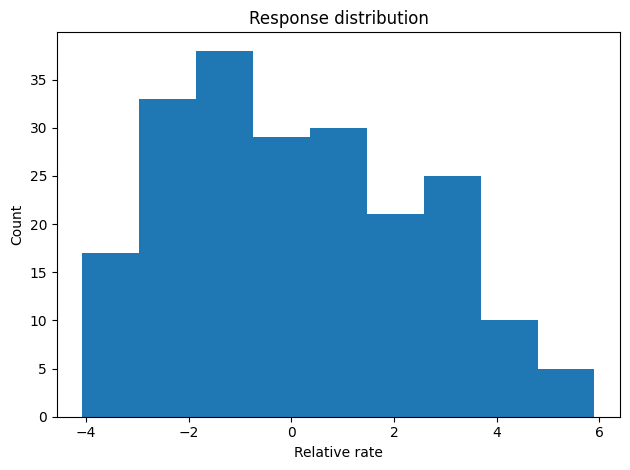

In [3]:
DATA_PATH      = "./InputData/aryl_rates_features.xlsx"
RESPONSE_LABEL = "Relative rate"
COLS_TO_REMOVE = [
]

data_df = pd.read_excel(DATA_PATH, sheet_name="Sheet1", index_col=0)
data_df = data_df.drop(columns=COLS_TO_REMOVE)  # avoid inplace= for cleaner flow

all_features = [c for c in data_df.columns if c != RESPONSE_LABEL]
print(f"Features ({len(all_features)}): {all_features}")

fig, ax = plt.subplots()
ax.hist(data_df[RESPONSE_LABEL], bins="auto")
ax.set_xlabel(RESPONSE_LABEL)
ax.set_ylabel("Count")
ax.set_title("Response distribution")
plt.tight_layout(); plt.show(); plt.close()

## Training/Validation/Test sets split
Split the entire data into training, validation, and test sets using random state = 42.

Train: 149  Val: 38  Test: 21
Train idx: ['L4_15' 'L5_23' 'L3_10' 'L3_40' 'L5_3' 'L6_3' 'L2_12' 'L2_35' 'L4_24'
 'L4_12' 'L1_38' 'L5_10' 'L3_4' 'L3_28' 'L2_8' 'L5_17' 'L2_26' 'L3_31'
 'L2_1' 'L3_11' 'L5_18' 'L1_44' 'L3_21' 'L4_5' 'L2_5' 'L2_30' 'L4_3'
 'L2_4' 'L2_34' 'L2_38' 'L3_38' 'L6_25' 'L3_30' 'L6_15' 'L3_37' 'L1_31'
 'L1_29' 'L1_1' 'L2_13' 'L5_13' 'L1_25' 'L3_20' 'L6_7' 'L4_9' 'L4_19'
 'L1_26' 'L4_2' 'L1_41' 'L5_19' 'L3_43' 'L1_11' 'L2_33' 'L1_15' 'L5_9'
 'L2_6' 'L3_8' 'L2_31' 'L3_22' 'L5_15' 'L6_18' 'L2_17' 'L4_36' 'L5_5'
 'L4_32' 'L6_9' 'L3_5' 'L6_23' 'L1_39' 'L6_8' 'L4_20' 'L5_11' 'L4_21'
 'L2_28' 'L2_18' 'L1_14' 'L3_25' 'L1_22' 'L1_4' 'L6_22' 'L2_20' 'L5_27'
 'L2_37' 'L3_41' 'L2_7' 'L5_14' 'L3_29' 'L1_5' 'L1_3' 'L6_14' 'L1_20'
 'L5_26' 'L3_12' 'L2_40' 'L1_40' 'L3_42' 'L4_11' 'L3_34' 'L2_2' 'L4_22'
 'L5_4' 'L2_23' 'L4_28' 'L1_9' 'L1_37' 'L4_25' 'L1_18' 'L4_23' 'L6_2'
 'L2_15' 'L2_11' 'L4_29' 'L6_19' 'L1_21' 'L6_20' 'L5_2' 'L6_13' 'L1_2'
 'L4_17' 'L6_27' 'L2_16' 'L1_42' 'L1_27'

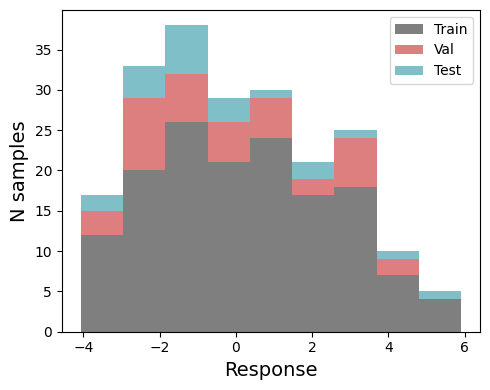

In [4]:
SPLIT_SEED     = 47
TEST_RATIO     = 0.10
VAL_RATIO      = 0.20  # fraction of the *remaining* train data

train_val_idx, test_idx = train_test_split(
    data_df.index, test_size=TEST_RATIO, random_state=SPLIT_SEED
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=VAL_RATIO, random_state=SPLIT_SEED
)
X_train = data_df.loc[train_idx].drop(columns=[RESPONSE_LABEL])
X_val   = data_df.loc[val_idx  ].drop(columns=[RESPONSE_LABEL])
X_test  = data_df.loc[test_idx ].drop(columns=[RESPONSE_LABEL])
y_train = data_df.loc[train_idx, RESPONSE_LABEL]
y_val   = data_df.loc[val_idx,   RESPONSE_LABEL]
y_test  = data_df.loc[test_idx,  RESPONSE_LABEL]

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print("Train idx:", train_idx.values)
print("Val idx  :", val_idx.values)
print("Test idx :", test_idx.values)

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist([y_train, y_val, y_test], bins="auto", alpha=0.5, stacked=True,
        label=["Train", "Val", "Test"], color=["black", "#BE0000", "#008090"])
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("N samples", fontsize=14)
ax.legend(loc="best")
plt.tight_layout(); plt.show(); plt.close()


## collinear feature cut using X_train
Features that are collinear (threshold > 0.90) are droped here. ## colinear feature cut using X_train

In [5]:
CORR_THRESHOLD = 0.90

corr_upper = X_train.corr().abs()
corr_upper = corr_upper.where(
    np.triu(np.ones(corr_upper.shape), k=1).astype(bool)
)
cols_to_drop = [c for c in corr_upper.columns if corr_upper[c].max() > CORR_THRESHOLD]

print(f"Dropping {len(cols_to_drop)} collinear features: {cols_to_drop}")
print(f"Features before: {X_train.shape[1]}  →  after: {X_train.shape[1] - len(cols_to_drop)}")

X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

Dropping 443 collinear features: ['HOMO_min_aryl', 'HOMO_max_aryl', 'HOMO_low_E_aryl', 'LUMO_min_aryl', 'LUMO_max_aryl', 'LUMO_low_E_aryl', 'μ_Boltz_aryl', 'μ_min_aryl', 'μ_max_aryl', 'μ_low_E_aryl', 'η_min_aryl', 'η_max_aryl', 'η_low_E_aryl', 'ω_Boltz_aryl', 'ω_min_aryl', 'ω_max_aryl', 'ω_low_E_aryl', 'polar_iso(Debye)_min_aryl', 'polar_iso(Debye)_max_aryl', 'polar_iso(Debye)_low_E_aryl', 'polar_aniso(Debye)_min_aryl', 'polar_aniso(Debye)_max_aryl', 'polar_aniso(Debye)_low_E_aryl', 'dipole(Debye)_low_E_aryl', 'SASA_surface_area(Å²)_Boltz_aryl', 'SASA_surface_area(Å²)_min_aryl', 'SASA_surface_area(Å²)_max_aryl', 'SASA_surface_area(Å²)_low_E_aryl', 'SASA_volume(Å³)_Boltz_aryl', 'SASA_volume(Å³)_min_aryl', 'SASA_volume(Å³)_max_aryl', 'SASA_volume(Å³)_low_E_aryl', 'SASA_sphericity_Boltz_aryl', 'SASA_sphericity_min_aryl', 'SASA_sphericity_max_aryl', 'SASA_sphericity_low_E_aryl', 'NBO_charge_X_min_aryl', 'NBO_charge_X_max_aryl', 'NBO_charge_X_low_E_aryl', 'NBO_charge_C_min_aryl', 'NBO_charg

# functions for modeling, feature importance, and plot
run this cell to define functions that are called later. 

In [6]:
os.makedirs("./OutputData/images", exist_ok=True)
save_path = "./OutputData/images/"
def print_metrics(label, y_true, y_pred):
    print(f"{label:10s}  R²={r2_score(y_true, y_pred):.3f}  MAE={mean_absolute_error(y_true, y_pred):.3f}")

def _plot_parity(y_train, y_val, y_test, y_train_pred, y_val_pred, y_test_pred, title):
    all_y = pd.concat([y_train, y_val] + ([y_test] if y_test is not None else []))
    lim_low, lim_high = all_y.min(), all_y.max()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_train, y_train_pred, c="#000000", alpha=0.5, label="Train", marker="o")
    ax.scatter(y_val,   y_val_pred,   c="#AF2418", alpha=0.7, label="Val",   marker="D")
    if y_test is not None and y_test_pred is not None:
        ax.scatter(y_test, y_test_pred, c="#377E8E", alpha=0.7, label="Test", marker="^")
    ax.plot([lim_low, lim_high], [lim_low, lim_high], "k--")
    ax.set_xlabel("True values"); ax.set_ylabel("Predicted values")
    ax.set_title(title); ax.legend()
    plt.tight_layout()
    plt.savefig(save_path + title.replace(" ", "_") + ".png", dpi=300, bbox_inches="tight")
    plt.show(); plt.close()

def run_rf_pass(X_train, X_val, y_train, y_val, pass_num):
    """
    Fit RandomizedSearchCV, evaluate on train/val, plot parity.
    Returns the best estimator and search object.
    """
    param_grid = {
        "n_estimators"     : [50, 100, 150],
        "max_depth"        : [3, 5, 7],
        "min_samples_split": [5, 10],
        "min_samples_leaf" : [2, 5],
        "bootstrap"        : [True],
    }
    search = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=SEED),
        param_distributions=param_grid,
        cv=5, n_jobs=N_JOBS,
        scoring="neg_mean_squared_error",
        random_state=SEED,
    )
    
    search.fit(X_train, y_train)
    model = search.best_estimator_

    print(f"Pass {pass_num} best params: {search.best_params_}")
    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)

    print_metrics("Train", y_train, y_train_pred)
    print_metrics("Val",   y_val,   y_val_pred)
    _plot_parity(y_train, y_val, None, y_train_pred, y_val_pred, None,
             title=f"random forest — pass {pass_num}")

    return model, search


def compute_permutation_importance(model, X_train, X_val, y_val, pass_num):
    """
    Compute and plot permutation importance on the val set.
    Returns a Series of mean importances indexed by feature name.
    """
    IMP_N_REPEATS = 30
    result = permutation_importance(
        model, X_val, y_val,
        n_repeats=IMP_N_REPEATS,
        random_state=SEED,
        n_jobs=N_JOBS,
        scoring="neg_mean_squared_error",
    )
    sorted_idx  = result.importances_mean.argsort()
    importances = pd.DataFrame(
        result.importances[sorted_idx].T,
        columns=X_train.columns[sorted_idx],
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.plot.box(vert=False, whis=10, ax=ax)
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    ax.set_title(f"Permutation importances — pass {pass_num} (validation set)")
    plt.tight_layout()
    plt.savefig(f"{save_path}permutation_importance_pass{pass_num}.png", dpi=300, bbox_inches="tight")
    plt.show(); plt.close()

    mean_imp = importances.mean().sort_values()
    print(f"Features below 0:     {(mean_imp < 0).sum()}")
    print(mean_imp.to_string())

    return mean_imp


def drop_features(X_train, X_val, mean_imp, threshold):
    """
    Drop features below threshold from train and val only.
    Apply final feature set to X_test once at the end.
    Returns trimmed (X_train, X_val).
    """
    to_drop = [f for f in mean_imp[mean_imp < threshold].index if f in X_train.columns]

    print(f"Dropping {len(to_drop)} features at threshold={threshold}: {to_drop}")
    print(f"Remaining: {X_train.shape[1] - len(to_drop)}")

    return (
        X_train.drop(columns=to_drop),
        X_val.drop(columns=to_drop),
    )

# RF model construction + feature reduction
run multiple iteration to reduce features until reasonable number of features. Workflow: 1. run RF model search, 2. compute permutation feature importances, 3. drop features that are less important. # RF model construction + feature reduction

#### iteration 1

Pass 1 best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'bootstrap': True}
Train       R²=0.958  MAE=0.357
Val         R²=0.848  MAE=0.697


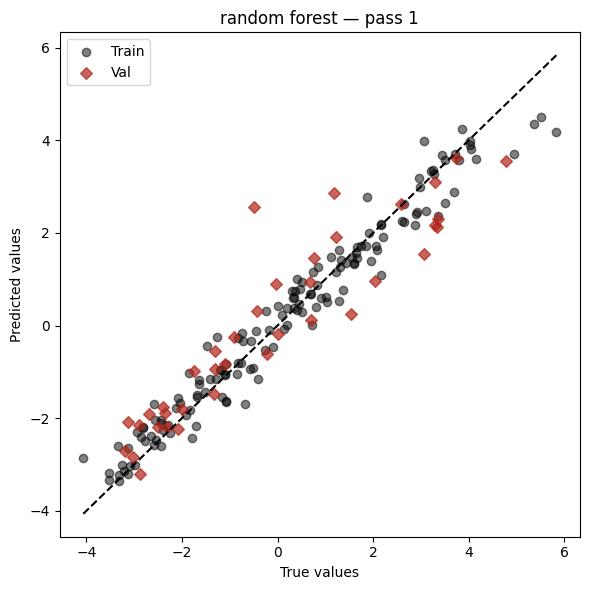

In [7]:
model1, search1 = run_rf_pass(X_train, X_val, y_train, y_val, pass_num=1)

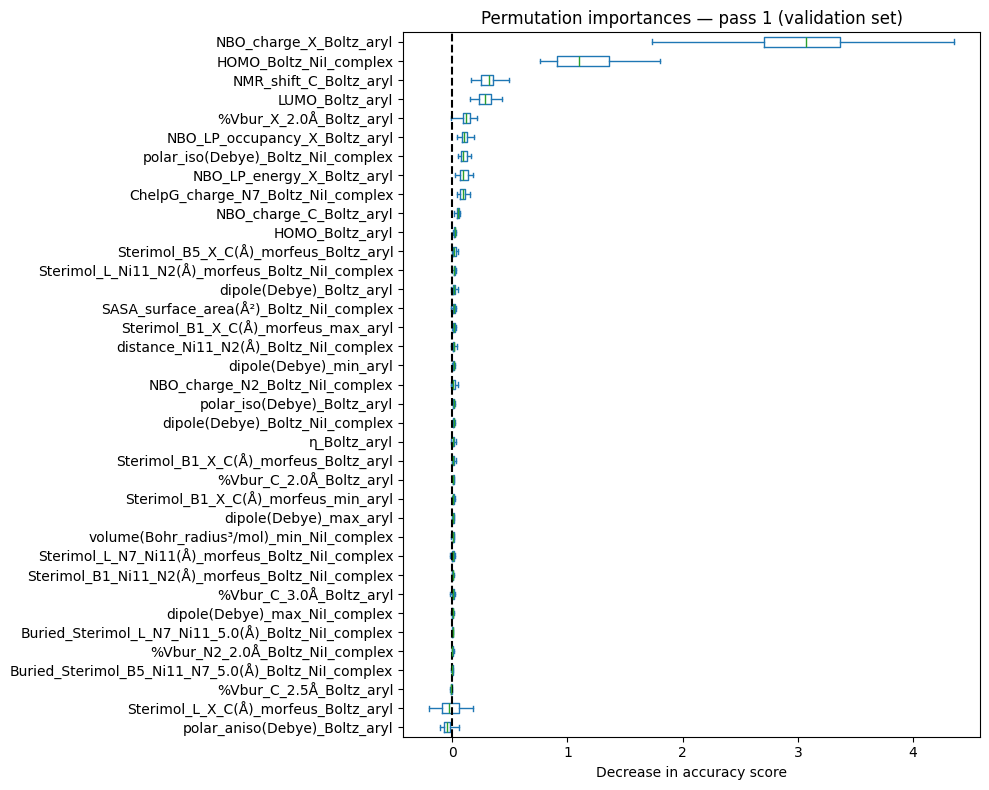

Features below 0:     3
polar_aniso(Debye)_Boltz_aryl                         -0.037484
Sterimol_L_X_C(Å)_morfeus_Boltz_aryl                  -0.023384
%Vbur_C_2.5Å_Boltz_aryl                               -0.007639
Buried_Sterimol_B5_Ni11_N7_5.0(Å)_Boltz_NiI_complex    0.001283
%Vbur_N2_2.0Å_Boltz_NiI_complex                        0.002543
Buried_Sterimol_L_N7_Ni11_5.0(Å)_Boltz_NiI_complex     0.003836
dipole(Debye)_max_NiI_complex                          0.004193
%Vbur_C_3.0Å_Boltz_aryl                                0.005484
Sterimol_B1_Ni11_N2(Å)_morfeus_Boltz_NiI_complex       0.006096
Sterimol_L_N7_Ni11(Å)_morfeus_Boltz_NiI_complex        0.007461
volume(Bohr_radius³/mol)_min_NiI_complex               0.008361
dipole(Debye)_max_aryl                                 0.009298
Sterimol_B1_X_C(Å)_morfeus_min_aryl                    0.010486
%Vbur_C_2.0Å_Boltz_aryl                                0.011050
Sterimol_B1_X_C(Å)_morfeus_Boltz_aryl                  0.011382
η_Boltz_aryl    

In [8]:
imp1 = compute_permutation_importance(model1, X_train, X_val, y_val, pass_num=1)

In [9]:
X_train_2, X_val_2 = drop_features(X_train, X_val, imp1, threshold=0)

Dropping 3 features at threshold=0: ['polar_aniso(Debye)_Boltz_aryl', 'Sterimol_L_X_C(Å)_morfeus_Boltz_aryl', '%Vbur_C_2.5Å_Boltz_aryl']
Remaining: 34


#### iteration 2

Pass 2 best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'bootstrap': True}
Train       R²=0.960  MAE=0.350
Val         R²=0.863  MAE=0.680


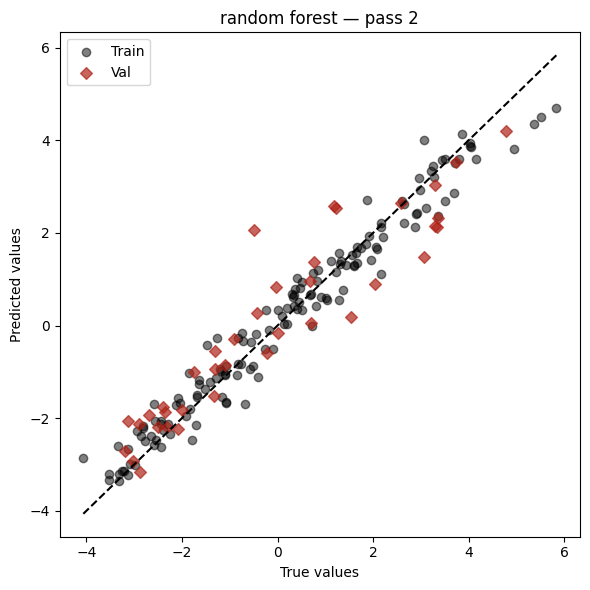

In [10]:
model2, search2 = run_rf_pass(X_train_2, X_val_2, y_train, y_val, pass_num=2)

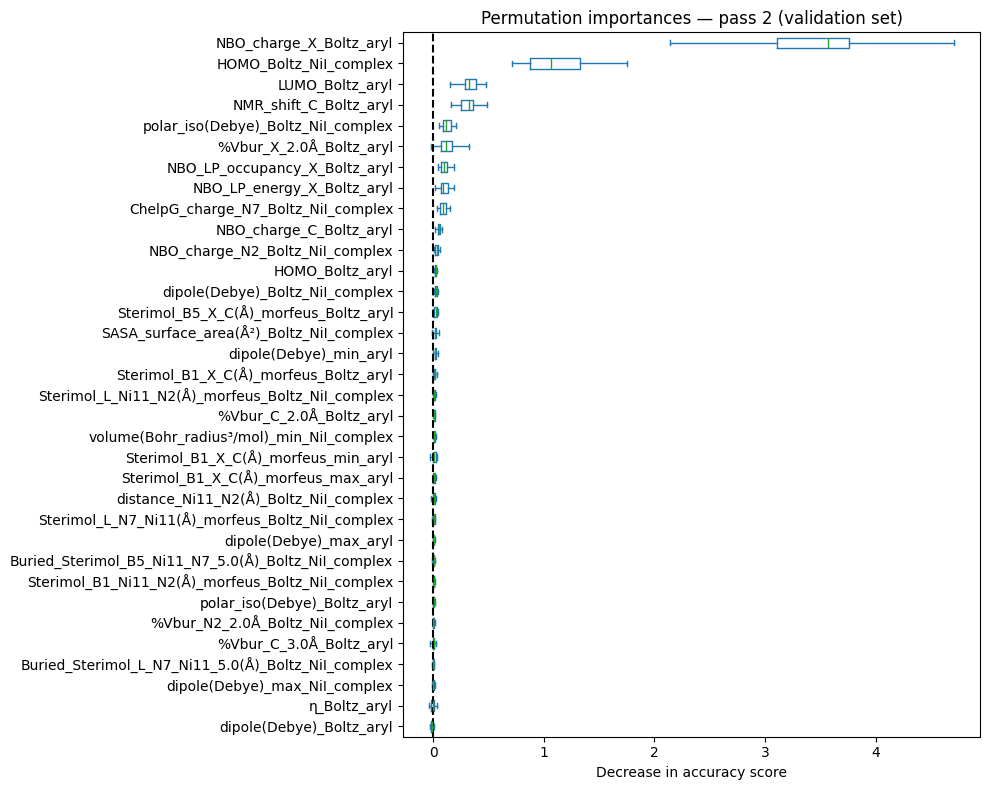

Features below 0:     2
dipole(Debye)_Boltz_aryl                              -0.010866
η_Boltz_aryl                                          -0.000131
dipole(Debye)_max_NiI_complex                          0.001306
Buried_Sterimol_L_N7_Ni11_5.0(Å)_Boltz_NiI_complex     0.002299
%Vbur_C_3.0Å_Boltz_aryl                                0.003559
%Vbur_N2_2.0Å_Boltz_NiI_complex                        0.003857
polar_iso(Debye)_Boltz_aryl                            0.006161
Sterimol_B1_Ni11_N2(Å)_morfeus_Boltz_NiI_complex       0.007140
Buried_Sterimol_B5_Ni11_N7_5.0(Å)_Boltz_NiI_complex    0.007165
dipole(Debye)_max_aryl                                 0.007406
Sterimol_L_N7_Ni11(Å)_morfeus_Boltz_NiI_complex        0.007476
distance_Ni11_N2(Å)_Boltz_NiI_complex                  0.008487
Sterimol_B1_X_C(Å)_morfeus_max_aryl                    0.008880
Sterimol_B1_X_C(Å)_morfeus_min_aryl                    0.009551
volume(Bohr_radius³/mol)_min_NiI_complex               0.010147
%Vbur_C_2.0Å_Bol

In [11]:
imp2 = compute_permutation_importance(model2, X_train_2, X_val_2, y_val, pass_num=2)

In [12]:
X_train_3, X_val_3 = drop_features(X_train_2, X_val_2, imp2, threshold=0.01)

Dropping 14 features at threshold=0.01: ['dipole(Debye)_Boltz_aryl', 'η_Boltz_aryl', 'dipole(Debye)_max_NiI_complex', 'Buried_Sterimol_L_N7_Ni11_5.0(Å)_Boltz_NiI_complex', '%Vbur_C_3.0Å_Boltz_aryl', '%Vbur_N2_2.0Å_Boltz_NiI_complex', 'polar_iso(Debye)_Boltz_aryl', 'Sterimol_B1_Ni11_N2(Å)_morfeus_Boltz_NiI_complex', 'Buried_Sterimol_B5_Ni11_N7_5.0(Å)_Boltz_NiI_complex', 'dipole(Debye)_max_aryl', 'Sterimol_L_N7_Ni11(Å)_morfeus_Boltz_NiI_complex', 'distance_Ni11_N2(Å)_Boltz_NiI_complex', 'Sterimol_B1_X_C(Å)_morfeus_max_aryl', 'Sterimol_B1_X_C(Å)_morfeus_min_aryl']
Remaining: 20


#### iteration 3

Pass 3 best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'bootstrap': True}
Train       R²=0.960  MAE=0.351
Val         R²=0.881  MAE=0.640


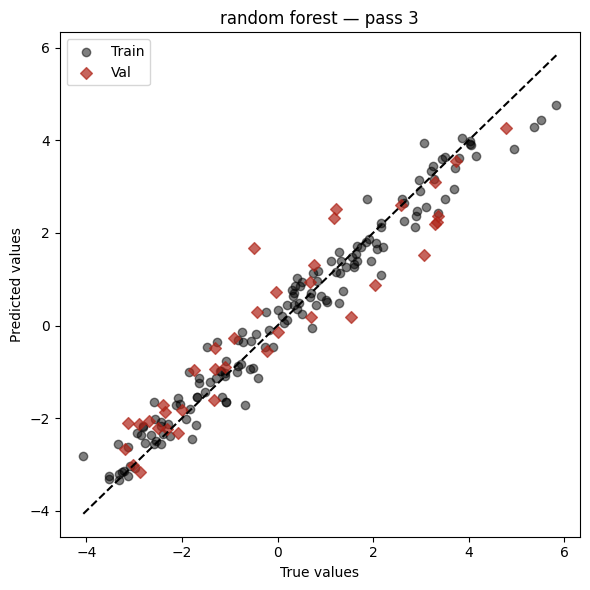

In [13]:
model3, search3 = run_rf_pass(X_train_3, X_val_3, y_train, y_val, pass_num=3)

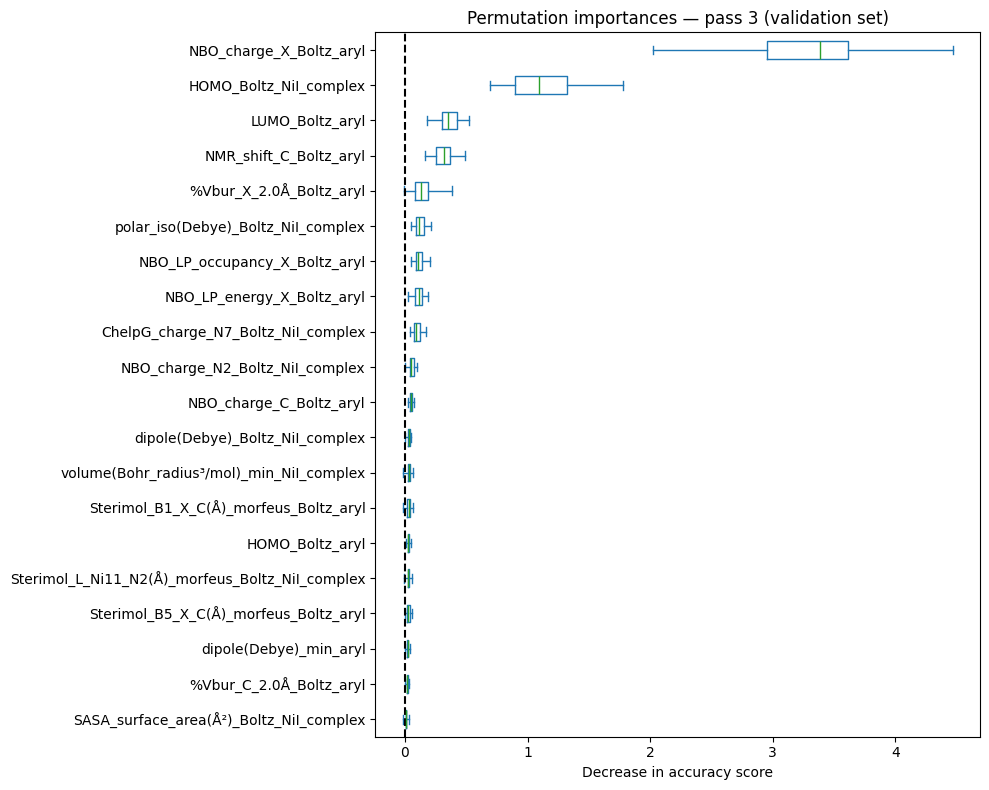

Features below 0:     0
SASA_surface_area(Å²)_Boltz_NiI_complex            0.009439
%Vbur_C_2.0Å_Boltz_aryl                            0.019303
dipole(Debye)_min_aryl                             0.022928
Sterimol_B5_X_C(Å)_morfeus_Boltz_aryl              0.028036
Sterimol_L_Ni11_N2(Å)_morfeus_Boltz_NiI_complex    0.028263
HOMO_Boltz_aryl                                    0.028468
Sterimol_B1_X_C(Å)_morfeus_Boltz_aryl              0.028578
volume(Bohr_radius³/mol)_min_NiI_complex           0.031059
dipole(Debye)_Boltz_NiI_complex                    0.031315
NBO_charge_C_Boltz_aryl                            0.049313
NBO_charge_N2_Boltz_NiI_complex                    0.050431
ChelpG_charge_N7_Boltz_NiI_complex                 0.100728
NBO_LP_energy_X_Boltz_aryl                         0.110101
NBO_LP_occupancy_X_Boltz_aryl                      0.115426
polar_iso(Debye)_Boltz_NiI_complex                 0.119274
%Vbur_X_2.0Å_Boltz_aryl                            0.144288
NMR_shift_C_Bolt

In [14]:
imp3 = compute_permutation_importance(model3, X_train_3, X_val_3, y_val, pass_num=3)

In [15]:
X_train_4, X_val_4 = drop_features(X_train_3, X_val_3, imp3, threshold=0.025)

Dropping 3 features at threshold=0.025: ['SASA_surface_area(Å²)_Boltz_NiI_complex', '%Vbur_C_2.0Å_Boltz_aryl', 'dipole(Debye)_min_aryl']
Remaining: 17


#### iteration 4

Pass 4 best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'bootstrap': True}
Train       R²=0.961  MAE=0.349
Val         R²=0.879  MAE=0.644


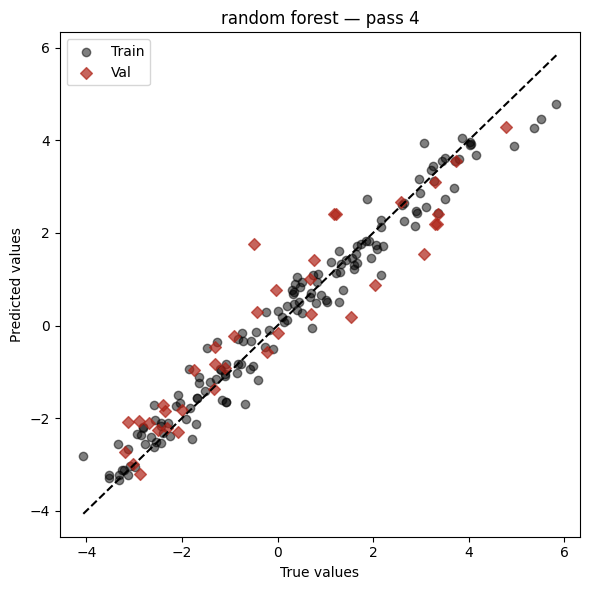

In [16]:
model4, search4 = run_rf_pass(X_train_4, X_val_4, y_train, y_val, pass_num=4)

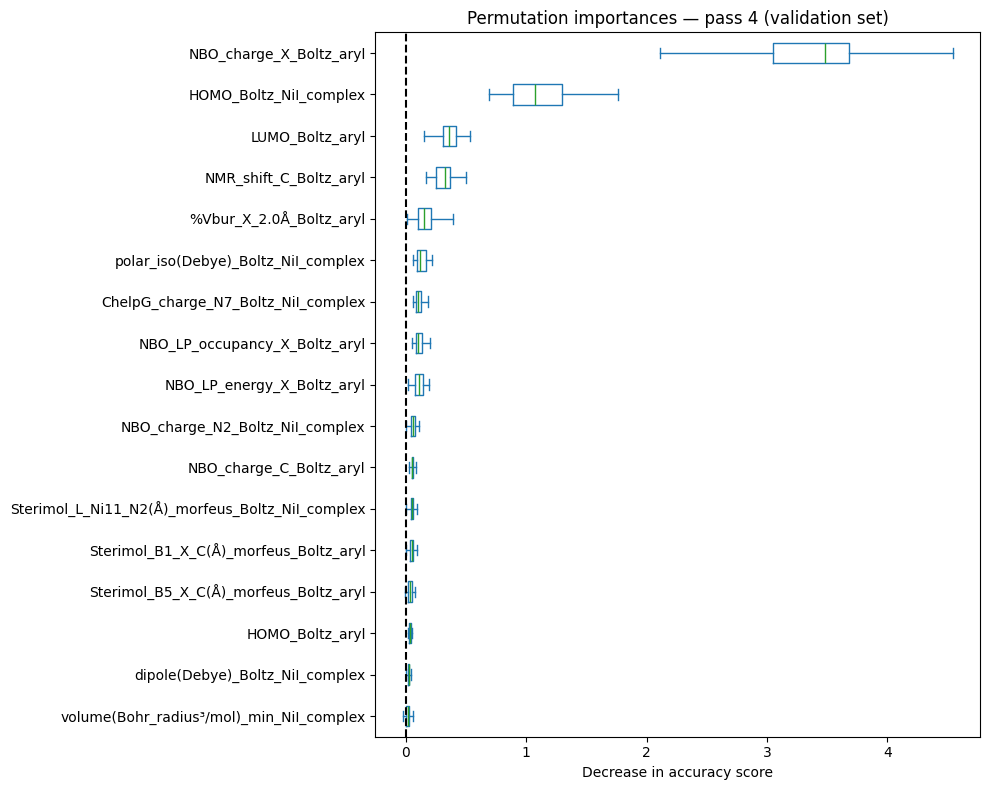

Features below 0:     0
volume(Bohr_radius³/mol)_min_NiI_complex           0.016882
dipole(Debye)_Boltz_NiI_complex                    0.021620
HOMO_Boltz_aryl                                    0.034293
Sterimol_B5_X_C(Å)_morfeus_Boltz_aryl              0.034792
Sterimol_B1_X_C(Å)_morfeus_Boltz_aryl              0.048428
Sterimol_L_Ni11_N2(Å)_morfeus_Boltz_NiI_complex    0.051260
NBO_charge_C_Boltz_aryl                            0.055148
NBO_charge_N2_Boltz_NiI_complex                    0.057638
NBO_LP_energy_X_Boltz_aryl                         0.108054
NBO_LP_occupancy_X_Boltz_aryl                      0.108319
ChelpG_charge_N7_Boltz_NiI_complex                 0.108354
polar_iso(Debye)_Boltz_NiI_complex                 0.126680
%Vbur_X_2.0Å_Boltz_aryl                            0.158042
NMR_shift_C_Boltz_aryl                             0.313258
LUMO_Boltz_aryl                                    0.361333
HOMO_Boltz_NiI_complex                             1.134909
NBO_charge_X_Bol

In [17]:
imp4 = compute_permutation_importance(model4, X_train_4, X_val_4, y_val, pass_num=4)

####
iteration 5

In [18]:
X_train_5, X_val_5 = drop_features(X_train_4, X_val_4, imp4, threshold=0.05)

Dropping 5 features at threshold=0.05: ['volume(Bohr_radius³/mol)_min_NiI_complex', 'dipole(Debye)_Boltz_NiI_complex', 'HOMO_Boltz_aryl', 'Sterimol_B5_X_C(Å)_morfeus_Boltz_aryl', 'Sterimol_B1_X_C(Å)_morfeus_Boltz_aryl']
Remaining: 12


Pass 5 best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'bootstrap': True}
Train       R²=0.960  MAE=0.350
Val         R²=0.877  MAE=0.633


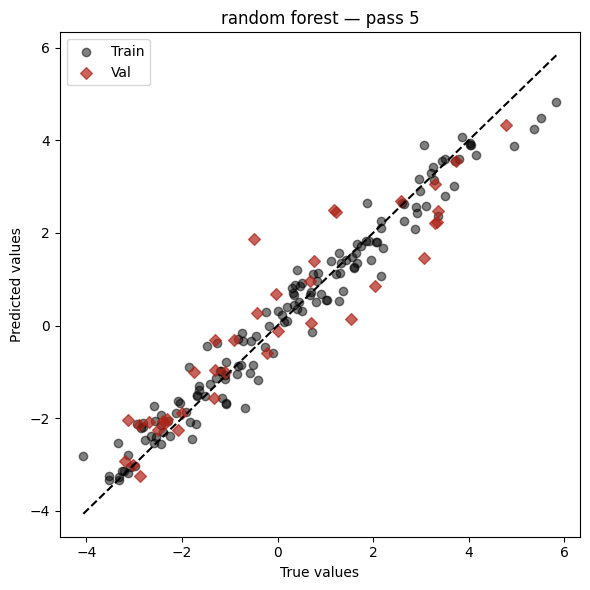

In [19]:
model5, search5 = run_rf_pass(X_train_5, X_val_5, y_train, y_val, pass_num=5)

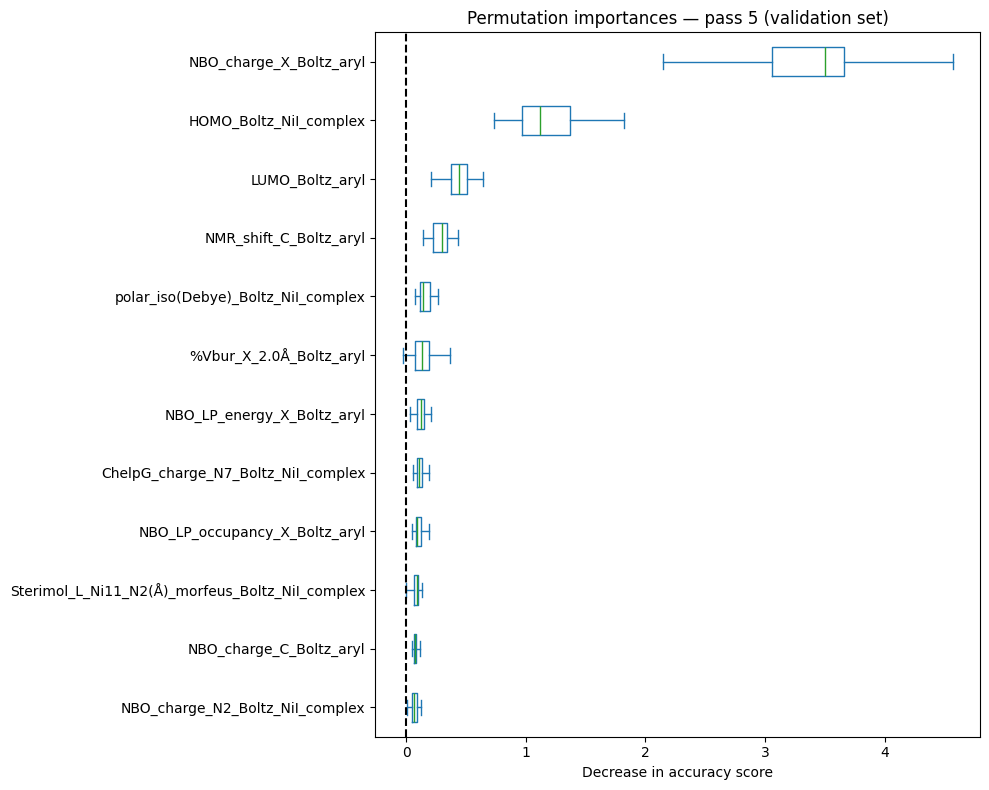

Features below 0:     0
NBO_charge_N2_Boltz_NiI_complex                    0.066752
NBO_charge_C_Boltz_aryl                            0.076347
Sterimol_L_Ni11_N2(Å)_morfeus_Boltz_NiI_complex    0.082875
NBO_LP_occupancy_X_Boltz_aryl                      0.105813
ChelpG_charge_N7_Boltz_NiI_complex                 0.112962
NBO_LP_energy_X_Boltz_aryl                         0.119468
%Vbur_X_2.0Å_Boltz_aryl                            0.136618
polar_iso(Debye)_Boltz_NiI_complex                 0.155780
NMR_shift_C_Boltz_aryl                             0.292206
LUMO_Boltz_aryl                                    0.437554
HOMO_Boltz_NiI_complex                             1.187888
NBO_charge_X_Boltz_aryl                            3.354271


In [20]:
imp5 = compute_permutation_importance(model5, X_train_5, X_val_5, y_val, pass_num=5)

# final model
Assign final model, and see the final features that remained. 

In [21]:
FINAL_MODEL = model5
cols = X_train_5.columns.tolist()
X_train, X_val, X_test = X_train_5.copy(), X_val_5.copy(), X_test[cols].copy()
FINAL_SEARCH = search5

In [22]:
cols

['LUMO_Boltz_aryl',
 'NBO_charge_X_Boltz_aryl',
 'NBO_charge_C_Boltz_aryl',
 'NMR_shift_C_Boltz_aryl',
 '%Vbur_X_2.0Å_Boltz_aryl',
 'NBO_LP_occupancy_X_Boltz_aryl',
 'NBO_LP_energy_X_Boltz_aryl',
 'HOMO_Boltz_NiI_complex',
 'polar_iso(Debye)_Boltz_NiI_complex',
 'NBO_charge_N2_Boltz_NiI_complex',
 'ChelpG_charge_N7_Boltz_NiI_complex',
 'Sterimol_L_Ni11_N2(Å)_morfeus_Boltz_NiI_complex']

### Shap analysis
shows top five features. 

In [ ]:
# ── font config  ──────
import matplotlib as mpl
mpl.rcParams["font.family"]      = "sans-serif"
mpl.rcParams["font.sans-serif"]   = ["Arial"]
mpl.rcParams["font.size"]         = 10
mpl.rcParams["axes.labelsize"]    = 10
mpl.rcParams["xtick.labelsize"]   = 9
mpl.rcParams["ytick.labelsize"]   = 9

# ── compute SHAP values once ──────────────────────────────────────
explainer   = shap.TreeExplainer(FINAL_MODEL)
shap_values = explainer.shap_values(X_val)

# ── clean up feature label strings ───────────────────────────────
X_labels = (
    X_train.columns
    .str.replace("_",        " ",             regex=False)
    .str.replace("C X",      "C-X",           regex=False)
    .str.replace(" Boltz",   "",              regex=False)
    .str.replace("NiI cat",  "NiI complex",   regex=False)
    .tolist()
)

# ── plot and save ─────────────────────────────────────────────────
SHAP_MAX_DISPLAY = 5
SHAP_PLOT_SIZE   = (6, 3)

shap.summary_plot(
    shap_values,
    X_val,
    feature_names=X_labels,
    max_display=SHAP_MAX_DISPLAY,
    plot_size=SHAP_PLOT_SIZE,
    show=False,
)
plt.savefig(save_path + "shap_summary.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show(); plt.close()

### plot test set
plot test set in the final model. 

Train       R²=0.960  MAE=0.350
Val         R²=0.877  MAE=0.633
Test        R²=0.864  MAE=0.690


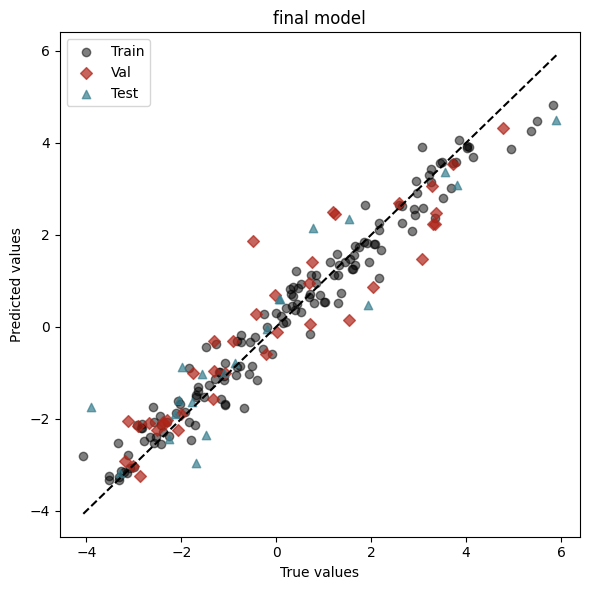

In [23]:
y_train_pred = FINAL_MODEL.predict(X_train)
y_val_pred   = FINAL_MODEL.predict(X_val)
y_test_pred  = FINAL_MODEL.predict(X_test)

# ── predictions & metrics ─────────────────────────────────────────
print_metrics("Train", y_train, y_train_pred)
print_metrics("Val", y_val, y_val_pred)
print_metrics("Test", y_test, y_test_pred)

# ── parity plot ───────────────────────────────────────────────────
_plot_parity(
    y_train, y_val, y_test,
    y_train_pred, y_val_pred, y_test_pred,
    title="final model"
)

#### save model details in joblib

In [ ]:
import joblib 

save_dict = {
    "model"         : FINAL_MODEL,
    "best_params"   : FINAL_SEARCH.best_params_,
    "seed"          : SEED,
    "features"      : X_train.columns.tolist(),
    "X_train"       : X_train,
    "X_val"         : X_val,
    "X_test"        : X_test,
    "y_train"       : y_train,
    "y_val"         : y_val,
    "y_test"        : y_test,
}

joblib.dump(save_dict, "rf_model_aryl_rates.joblib")
print("Saved:", list(save_dict.keys()))

#### import saved model 
if importing joblib, run cells for import, model/feature importance/plot functions, and plot test set.  

In [ ]:
import joblib

saved = joblib.load("rf_model_aryl_rates.joblib")

# unpack what you need
FINAL_MODEL = saved["model"]
X_train     = saved["X_train"]
X_val       = saved["X_val"]
X_test      = saved["X_test"]
y_train     = saved["y_train"]
y_val       = saved["y_val"]
y_test      = saved["y_test"]
features    = saved["features"]
best_params = saved["best_params"]
SEED        = saved["seed"]

print("Loaded model trained on features:", features)

#### save results
makes an excel file with predicted relative rate and absolute rate and data type (train, validation, or test)

In [ ]:
K1 = 7.95
OUTPUT_FILE = "./OutputData/rf_predictions_with_kx_input_aryls.xlsx"

def make_pred_df(X, y_true, y_pred, label):
    return (
        X.assign(**{
            "Measured_ln(kx/k1)":  y_true.values,
            "Predicted_ln(kx/k1)": y_pred,
            "Measured_kx":         np.exp(y_true.values) * K1,
            "Predicted_kx":        np.exp(y_pred)        * K1,
            "Set":                 label,
        })
    )

splits = [
    (X_train, y_train, y_train_pred, "Train"),
    (X_val,   y_val,   y_val_pred,   "Validation"),
    (X_test,  y_test,  y_test_pred,  "Test"),
]

combined_df = pd.concat([make_pred_df(*s) for s in splits], ignore_index=False)
combined_df.to_excel(OUTPUT_FILE, index=True)
print(f"Saved {len(combined_df)} rows to {OUTPUT_FILE}")

# Predicting
predicts relative rates and absolute rates for chloride and bromide library. "

In [ ]:
# INPUT_FILE          = "./InputData/arbr_lib_combined_high_corr_feat.xlsx"
# OUTPUT_PREDICTIONS  = "./OutputData/ArylBrlib_all_L_predicted.xlsx"

INPUT_FILE          = "./InputData/arcl_lib_predicted_props_from_arbr.xlsx"
OUTPUT_PREDICTIONS  = "./OutputData/ArylCllib_all_L_predicted.xlsx"

all_sheets = pd.ExcelFile(INPUT_FILE).sheet_names

# determine shared features using first sheet
sample_df = pd.read_excel(INPUT_FILE, sheet_name=all_sheets[0])

# normalise column names to match training data
sample_df = sample_df.rename(columns={
    col: col if (
        col in ["id", "smiles"] or 
        col.endswith("_complex") or 
        col.endswith("_aryl")
    )
    else f"{col}_aryl"
    for col in sample_df.columns
})

sample_df = sample_df.rename(columns={
    col: col.replace("_cat", "_NiI_cat")
    for col in sample_df.columns
    if col.endswith("_cat")
})

# keep only features present in both training and prediction data
common_cols = [c for c in X_train.columns if c in sample_df.columns]
print(f"Using {len(common_cols)} / {len(X_train.columns)} features")

# retrain model on reduced feature set
X_train_reduced = X_train[common_cols]
FINAL_MODEL.fit(X_train_reduced, y_train)

with pd.ExcelWriter(OUTPUT_PREDICTIONS) as writer:
    for sheet in all_sheets:
        pred_df = pd.read_excel(INPUT_FILE, sheet_name=sheet)

        # normalise column names to match training data
        pred_df = pred_df.rename(columns={
            col: col if (
                col in ["id", "smiles"] or 
                col.endswith("_complex") or 
                col.endswith("_aryl")
            )
            else f"{col}_aryl"
            for col in pred_df.columns
        })

        pred_df = pred_df.rename(columns={
            col: col.replace("_cat", "_NiI_cat")
            for col in pred_df.columns
            if col.endswith("_cat")
        })

        # select matching features
        X_virtual = pred_df[common_cols]

        # predict
        y_virtual_pred          = FINAL_MODEL.predict(X_virtual)
        pred_df["Predicted_ln(kx/k1)"] = y_virtual_pred
        pred_df["Predicted_kx"]        = np.exp(y_virtual_pred) * K1

        pred_df.to_excel(writer, sheet_name=sheet, index=False)
        print(f"[{sheet}] {len(pred_df)} rows predicted and saved")

print(f"\nDone. Sheets saved: {len(all_sheets)}")

# Leave one group out (LOGO) analysis
perform leave one substrate out (LOSO) and leave one catalyst out (LOCO) analyses# Leave one out analysis

#### make df for LOSO and LOCO analyses
make full_df by combining the final features, relative rates, and index (label = LX_alkylxxx). split label LX_alkylxxx to LX (catalyst) and alkylxxx (substrate).

In [ ]:
# ── build full-dataset design matrix ─────────────────────────────
feature_cols = X_train.columns.tolist()

full_df = data_df[feature_cols + [RESPONSE_LABEL]].copy()
full_df = full_df.reset_index()   # Reaction_ID becomes a column
full_df["Catalyst"]  = full_df["Reaction_ID"].str.split("_").str[0]
full_df["Substrate"] = full_df["Reaction_ID"].str.split("_").str[1]

X_full = full_df[feature_cols]
y_full = full_df[RESPONSE_LABEL]

print(f"Full dataset: {len(full_df)} rows  |  features: {X_full.shape[1]}")
print(full_df[["Reaction_ID", "Catalyst", "Substrate"]].head())

#### LOGO functions
define functions for leave one group out (both LOSO and LOCO)

In [ ]:
# ── reusable LOGO runner ──────────────────────────────────────────
def run_logo(X, y, groups, group_label, plot_dir, output_file):
    """
    Run Leave-One-Group-Out CV, save per-fold plots and a summary Excel.

    Parameters
    ----------
    group_label : str   column label used in results_df and plot titles
    plot_dir    : str   folder for per-fold scatter plots
    output_file : str   path for the summary Excel file
    """
    os.makedirs(plot_dir, exist_ok=True)
    
    logo    = LeaveOneGroupOut()
    results = []
    
    for i, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups)):
        group_name = groups[te_idx[0]]

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # refit final model architecture on this fold's training data
        fold_model = RandomForestRegressor(**FINAL_SEARCH.best_params_, random_state=SEED)
        fold_model.fit(X_tr, y_tr)

        y_tr_pred = fold_model.predict(X_tr)
        y_te_pred = fold_model.predict(X_te)

        mae_tr  = mean_absolute_error(y_tr, y_tr_pred)
        r2_tr   = r2_score(y_tr, y_tr_pred)
        mae_te  = mean_absolute_error(y_te, y_te_pred)
        r2_te   = r2_score(y_te, y_te_pred)
        kx_err  = K1 * np.exp(mae_te)

        # per-fold parity plot
        all_y   = pd.concat([y_tr, y_te])
        lim_low, lim_high = all_y.min(), all_y.max()

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(y_tr, y_tr_pred, alpha=0.5, label="Train")
        ax.scatter(y_te, y_te_pred, alpha=0.7, label="Left out")
        ax.plot([lim_low, lim_high], [lim_low, lim_high], "k--")
        ax.set_xlabel("True values"); ax.set_ylabel("Predicted values")
        ax.set_title(
            f"{group_label} {group_name}\n"
            f"MAE={mae_te:.2f}  kx err={kx_err:.2f}"
        )
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/logo_{group_name}.png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close()

        results.append({
            "fold"      : i,
            group_label : group_name,
            "r2_train"  : r2_tr,
            "mae_train" : mae_tr,
            "r2_val"    : r2_te,
            "mae_val"   : mae_te,
        })

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    print(f"\nMean val MAE: {results_df['mae_val'].mean():.4f}")
    results_df.to_excel(output_file, index=False)
    print(f"Saved: {output_file}\n")
    return results_df

#### LOSO 

In [ ]:
# ── leave-one-substrate-out ───────────────────────────────────────
loso_results = run_logo(
    X_full, y_full,
    groups      = full_df["Substrate"].values,
    group_label = "Substrate",
    plot_dir    = "./logo/substrate",
    output_file = "./OutputData/LOSO_aryl.xlsx",
)

#### LOCO

In [ ]:
# ── leave-one-catalyst-out ────────────────────────────────────────
loco_results = run_logo(
    X_full, y_full,
    groups      = full_df["Catalyst"].values,
    group_label = "Catalyst",
    plot_dir    = "./logo/catalyst",
    output_file = "./OutputData/LOCO_aryl.xlsx",
)

The end of RF aryl rate model script 